In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score

In [39]:
df = pd.read_csv(r"C:\Users\Georgina\Desktop\ProjecteData\Equip_18\Data\101125_dataset.csv", sep=';')
#df.sample(3)

In [40]:
# Revisar los nulos en el df
df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
age_group    0
dtype: int64

In [41]:
def age_groups(x):

    '''Clasifica el valor de edad numérico dentro de un rango
       ----------
       Parámetro
       x : float - Edad de una persona.
       -------
       Retorna        
       Grupo de edad correspondiente según los siguientes rangos:
       - 'joven' : si la edad es menor o igual a 25
       - 'adulto_joven' : si la edad es menor o igual a 35
       - 'adulto'    : si la edad es menor o igual a 55
       - 'senior' : en el resto de rango de edades'''

    if x <= 25:
        return 'joven'
    elif x <= 35:
        return 'adulto_joven'
    elif x <= 55:
        return 'adulto'
    else:
        return 'senior'
    
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df['age_group2'] = df['age'].apply(age_groups)

# Verificacion de distribución
(df['age_group2'].value_counts(normalize=True)).round(2)

age_group2
adulto          0.48
adulto_joven    0.35
senior          0.14
joven           0.04
Name: proportion, dtype: float64

In [42]:
def simplify_job(job):

    '''     Clasifica cada valor dentro de una categoría nueva de empleos
       ----------
       Parámetro
       x : object - Profesión de cada cliente.
       -------
       Retorna        
       Etiqueta de nueva catgorización de los empleos:
       - 'profesional' : si los valores son 'management', 'technician', 'administrative', 'services'
       - 'operativo' : si el valor es blue-collar
       - 'autonomo'  : si los valores son 'self-employed', 'entrepreneur'
       - 'jubilado' : si 'retired'
       - no_activo : si los valores son 'unemployed', 'student', 'housemaid'
       - 'otros' : en el resto de los casos
       '''
      
    job = str(job).lower().strip()
    if job in ['management', 'technician', 'administrative', 'services']:
        return 'profesional'
    elif job in ['blue-collar']:
        return 'operativo'
    elif job in ['self-employed', 'entrepreneur']:
         return 'autonomo'
    elif job in ['retired']:
        return 'jubilado'
    elif job in ['unemployed', 'student', 'housemaid']:
        return 'no_activo'
    else:
        return 'otros'

    
# Aplicar la función y crear una columna nueva job_cat
df['job_cat'] = df['job'].apply(simplify_job)

# Verificacion de distribución
(df['job_cat'].value_counts(normalize=True)).round(2)

job_cat
profesional    0.60
operativo      0.18
no_activo      0.09
jubilado       0.07
autonomo       0.07
Name: proportion, dtype: float64

In [43]:
# Education

def simplify_edu(edu):
    edu = str(edu).lower()
    if 'primary' in edu:
        return 'baja'
    elif 'secondary' in edu:
        return 'media'
    else:
        'tertiary' in edu or 'university' in edu
        return 'alta'

df['education_level'] = df['education'].apply(simplify_edu)

# Verificacion de la distribución
(df['education_level'].value_counts(normalize=True)).round(2)

education_level
media    0.52
alta     0.34
baja     0.14
Name: proportion, dtype: float64

In [44]:
# Seleccionar las variables para el clustering
demo_vars = ['age_group2', 'job_cat', 'education_level', 'marital']
df_cat = df[demo_vars].copy()

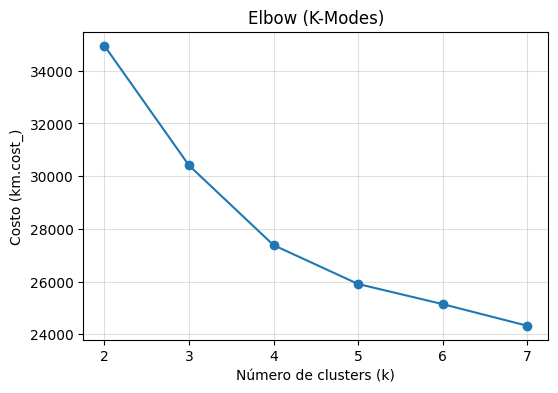

In [45]:
# Metodo de codo (Elbow) para KModes para encontar el número óptimo de clusters
K = range(2, 8)
cost = []

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0, random_state=42) # se pueden usar init= Cao o Huang
    km.fit_predict(df_cat)
    cost.append(km.cost_)

plt.figure(figsize=(6,4))
plt.plot(K, cost, marker='o')
plt.title('Elbow (K-Modes)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Costo (km.cost_)')
plt.grid(alpha=0.4)
plt.show()


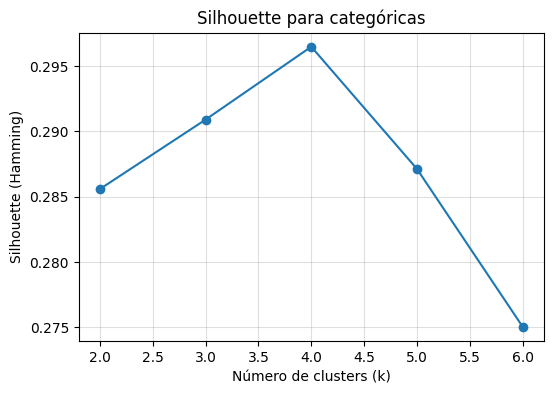

In [46]:
# Codificar variables categóricas como números para calcular silhouette (métrica Hamming), encontrar número óptimo de clusters
df_encoded = df_cat.copy()
for col in df_encoded.columns:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

sil_scores = []
K = range(2, 7)

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    clusters = km.fit_predict(df_cat)
    score = silhouette_score(df_encoded, clusters, metric='hamming')
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette para categóricas')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette (Hamming)')
plt.grid(alpha=0.4)
plt.show()


## kmode algoritmo

In [47]:
# Definir como número de clusters 5 

kmode = KModes(n_clusters=5, init = "Cao", n_init = 10, verbose=1, random_state=42) # se puede probar con Cao en init o Huang
clusters = kmode.fit_predict(df_cat)
clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1986, cost: 25911.0


array([0, 0, 0, ..., 0, 3, 1], dtype=uint16)

In [48]:
# Añadir en df original y df_cat la columna con los clusters generados

df['Cluster'] = clusters 
df_cat['Cluster'] = clusters

In [49]:
cluster_modes = pd.DataFrame(kmode.cluster_centroids_, columns=demo_vars)

cluster_modes.index = [f'Cluster_{i}' for i in range(len(cluster_modes))]

print(cluster_modes)

             age_group2      job_cat education_level  marital
Cluster_0        adulto  profesional           media  married
Cluster_1  adulto_joven  profesional            alta   single
Cluster_2        adulto    operativo            baja  married
Cluster_3  adulto_joven    operativo           media   single
Cluster_4        senior    no_activo            alta  married


In [50]:
#categorizar balance
# # Definir los límites de los rangos

blce_min, blce_max = df.balance.agg(['min', 'max'])

bins = [blce_min, 0, 500, 2000, blce_max]

labels = ['Negativo' , 'Bajo', 'Medio', 'Alto']

df['balance_bins'] = pd.cut(df.balance, bins = [blce_min, 0, 500, 2000, blce_max], include_lowest=True)

df['balance_cat'] = pd.cut(df.balance, bins = bins, labels=labels, include_lowest= True)

#df.balance_bins.cat.categories

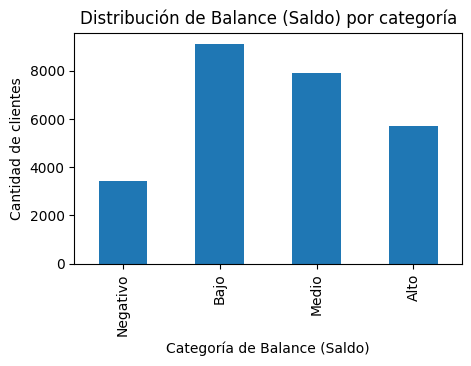

In [51]:
# Grafico

plt.figure(figsize=(5, 3))  # ancho = 5, alto = 3
df.balance_cat.value_counts().sort_index().plot.bar()
plt.xlabel('Categoría de Balance (Saldo)')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de Balance (Saldo) por categoría')
plt.show()


### Clusters agrupados

In [52]:
# Agrupamiento de Clusters | De 5 a 3

mapa_clusters = {2:0, 0:0, 1:1, 3:1, 4:2}
df['cluster2'] = df['Cluster'].map(mapa_clusters)

In [53]:
name_clusters = {0:'Family', 1:'Dynamic', 2:'Premium_Senior'}
df['name_clusters'] = df['cluster2'].map(name_clusters)

In [54]:
df['name_clusters'].value_counts()
#df['name_clusters'].value_counts().plot.bar()

name_clusters
Family            16011
Dynamic            9044
Premium_Senior     1121
Name: count, dtype: int64

age_group2      adulto  adulto_joven  joven  senior
name_clusters                                      
Dynamic           1085          7063    699     197
Family           11284          2033    327    2367
Premium_Senior      98            40      6     977


<Axes: xlabel='name_clusters'>

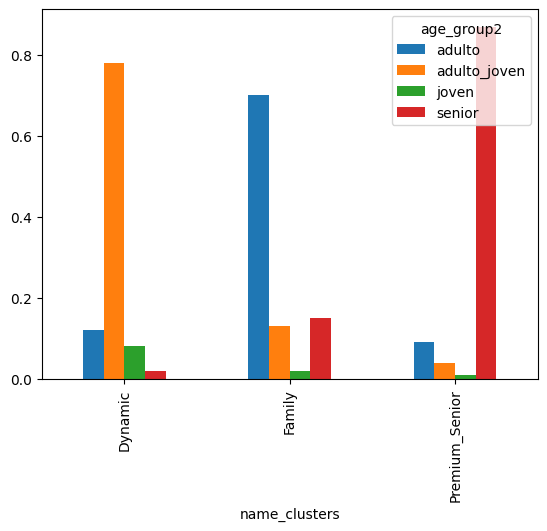

In [55]:
print(pd.crosstab(df['name_clusters'], df['age_group2']))

pd.crosstab(df['name_clusters'], df['age_group2'], normalize='index').round(2).plot.bar()

marital         divorced  married  single
name_clusters                            
Dynamic              359     1858    6827
Family              2540    12062    1409
Premium_Senior       145      963      13


<Axes: xlabel='name_clusters'>

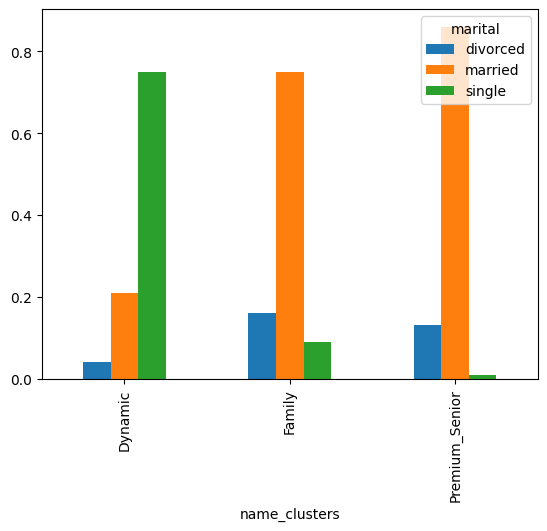

In [56]:
print(pd.crosstab(df.name_clusters, df.marital))
pd.crosstab(df.name_clusters, df.marital, normalize='index').round(2).plot.bar()

job_cat         autonomo  jubilado  no_activo  operativo  profesional
name_clusters                                                        
Dynamic              546        47       1066       1691         5694
Family              1053      1540        882       2937         9599
Premium_Senior       108       275        379          0          359


<Axes: xlabel='name_clusters'>

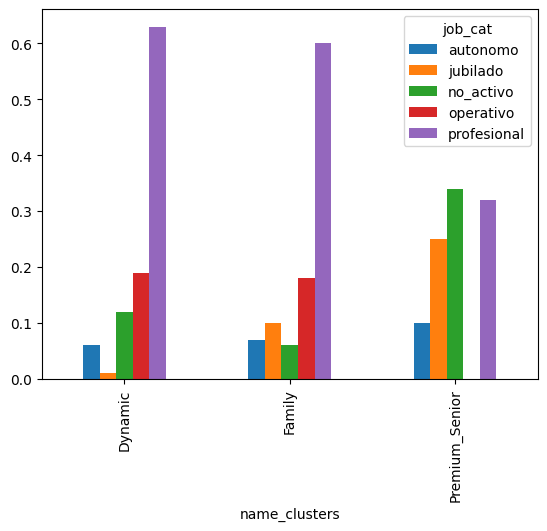

In [57]:
print(pd.crosstab(df.name_clusters, df.job_cat))
pd.crosstab(df.name_clusters, df.job_cat, normalize='index').round(2).plot.bar()

education_level  alta  baja  media
name_clusters                     
Dynamic          5020   269   3755
Family           2952  3313   9746
Premium_Senior    911   133     77


<Axes: xlabel='name_clusters'>

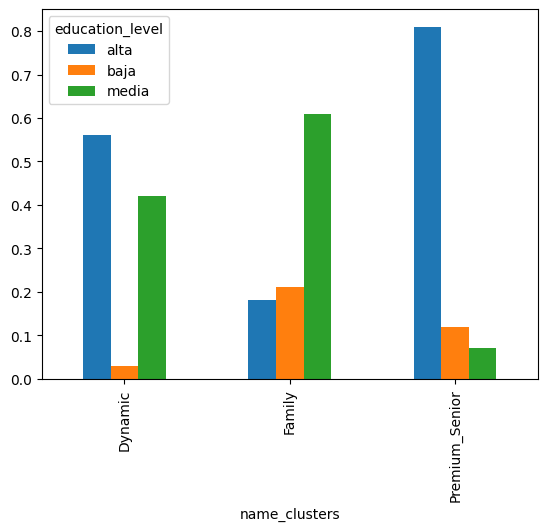

In [58]:
print(pd.crosstab(df.name_clusters, df.education_level))
pd.crosstab(df.name_clusters, df.education_level, normalize='index').round(2).plot.bar()

default            no  yes
name_clusters             
Dynamic          8919  125
Family          15756  255
Premium_Senior   1107   14


<Axes: xlabel='name_clusters'>

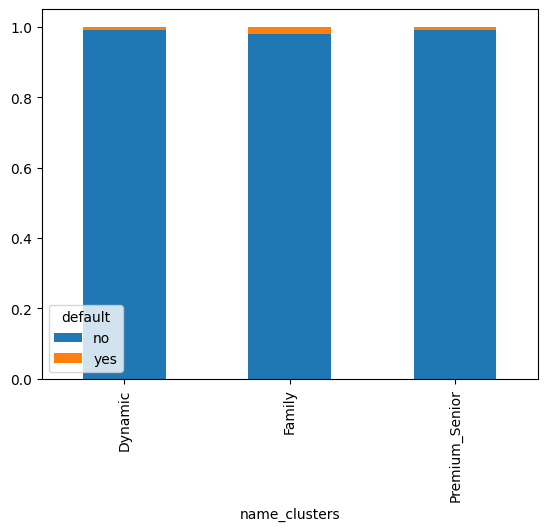

In [59]:
# ANalisis de comportamiento financiero por perfil cliente (cluster)

print(pd.crosstab(df['name_clusters'], df['default']))
pd.crosstab(df['name_clusters'], df['default'], normalize='index').round(2).plot.bar(stacked=True)


balance_cat     Negativo  Bajo  Medio  Alto
name_clusters                              
Dynamic              968  3475   2811  1790
Family              2331  5396   4777  3507
Premium_Senior       125   245    330   421


<Axes: xlabel='name_clusters'>

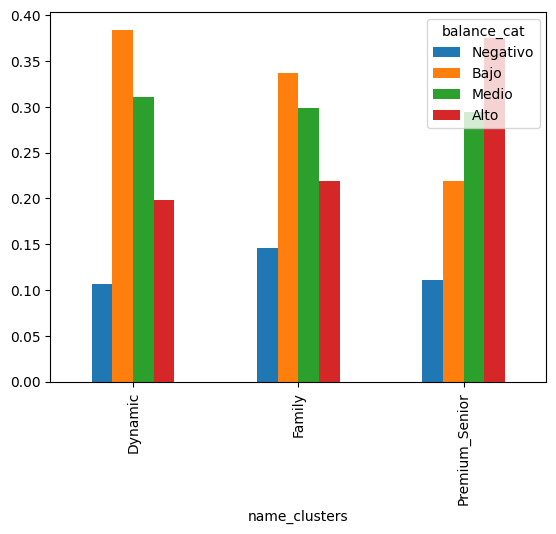

In [60]:
print(pd.crosstab(df['name_clusters'], df['balance_cat']))
pd.crosstab(df['name_clusters'], df['balance_cat'], normalize= 'index').plot.bar()

In [61]:
pd.crosstab(df['name_clusters'], [df['balance_cat'], df['default']])

balance_cat    Negativo       Bajo     Medio      Alto    
default              no  yes    no yes    no yes    no yes
name_clusters                                             
Dynamic             895   73  3430  45  2804   7  1790   0
Family             2174  157  5315  81  4763  14  3504   3
Premium_Senior      120    5   245   0   321   9   421   0

                mean  median
name_clusters               
Dynamic         1407     517
Family          1538     544
Premium_Senior  2379    1238


' Dynamic y Family tiene un perfil de balance_cat BAJO (0 - 500), pero el 50% de los clientes esta por encima de EU 517/544\n- Dynamic y Family están justo en el límite entre "bajo" y "medio" → un 50% están por encima lo que los ubica en la categoría "medio".\n- Premium_Senior tiene un perfil de balance_cat ALTO (+ 2000), pero el 50% de los clientes esta por debajo de EU 1238\n → dentro de la categoría "medio"\n'

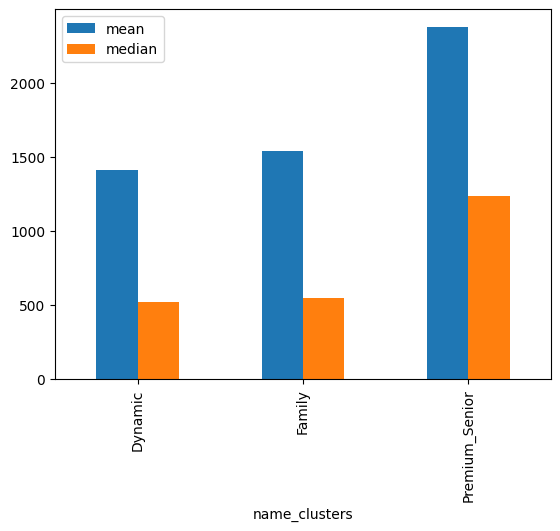

In [62]:
cluster_desc_balance = df.groupby('name_clusters')['balance'].agg(['mean', 'median']).astype(int)
print(cluster_desc_balance)

df.groupby('name_clusters')['balance'].agg(['mean', 'median']).plot.bar()

''' Dynamic y Family tiene un perfil de balance_cat BAJO (0 - 500), pero el 50% de los clientes esta por encima de EU 517/544
- Dynamic y Family están justo en el límite entre "bajo" y "medio" → un 50% están por encima lo que los ubica en la categoría "medio".
- Premium_Senior tiene un perfil de balance_cat ALTO (+ 2000), pero el 50% de los clientes esta por debajo de EU 1238
 → dentro de la categoría "medio"
'''

In [63]:
# Perfil PREDOMINANTE por CLuster

def perfil_pred_cluster(Xgrupo):
    
    default_predom = Xgrupo['default'].value_counts().idxmax()
    balance_predom = Xgrupo['balance_cat'].value_counts().idxmax()
    return pd.Series({'default_status': default_predom, 'balance_status': balance_predom})

perfiles = df.groupby('name_clusters').apply(perfil_pred_cluster)

perfiles

C:\Users\Georgina\AppData\Local\Temp\ipykernel_30400\131048587.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  perfiles = df.groupby('name_clusters').apply(perfil_pred_cluster)


,default_status,balance_status
name_clusters,,
Dynamic,no,Bajo
Family,no,Bajo
Premium_Senior,no,Alto


In [64]:
#df.to_csv(r"C:\Users\tinke\Desktop\simulador empresarial\031125dataset_prueba.csv",sep=";",index=False)

df.to_csv(r"C:\Users\Georgina\Desktop\Simulador2\clusters_agrupados_3_Week3.csv", sep=";", index=False)

## Test Chi2

In [65]:
variables = ['balance_cat', 'default']
for variable in variables:
    contingency = pd.crosstab(df['name_clusters'], df[variable])

    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi2: {chi2:.3f}, p-value: {p:.5f}")

    if p < 0.05:
        print(f"P-value es {p:.5f}, que sugiere que hay una associación estadisticamente significativa entre las variables 'name_clusters' y {variable}")
    else:
        print(f"P-value es {p:.5f}, que sugiere que NO hay una associación estadisticamente significativa entre las variables 'name_clusters' y {variable}")

Chi2: 309.938, p-value: 0.00000
P-value es 0.00000, que sugiere que hay una associación estadisticamente significativa entre las variables 'name_clusters' y balance_cat
Chi2: 2.247, p-value: 0.32519
P-value es 0.32519, que sugiere que NO hay una associación estadisticamente significativa entre las variables 'name_clusters' y default
